# 0. Описание задачи

**Цель:** Создать модель машинного обучения для прогнозирования успешности краудфандингового проекта на платформе Kickstarter.

**Целевые классы:**
- `successful` - успешный
- `failed` - неудачный  
- `canceled` - отмененный

**Основные признаки:**
- Категория проекта
- Страна
- Цель финансирования
- Количество спонсоров
- Длительность кампании
- Временные метки (дата запуска, дедлайн)

**Тип задачи:** Kлассификация (предсказание класса успешности проекта)

# 1. Чтение данных

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

data = pd.read_csv("kickstarter_dataset.csv", encoding='latin1', low_memory=False)

In [15]:
display(HTML(data.head().to_html(index=False)))

ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
1000011046,Community Film Project: The Art of Neighborhood Filmmaking,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


# 2. Обучающая и тестовая выборки

In [25]:
import pandas as pd
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split

data.columns = data.columns.str.strip()
data_cleaned = data.drop(columns=['ID', 'name', 'deadline', 'launched'], errors='ignore')
data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.str.contains('^Unnamed')]

display(HTML(data_cleaned.head().to_html(index=False)))

class_counts = data_cleaned['state'].value_counts()
print("Распределение классов:")
print(class_counts)

filtered_data = data_cleaned.groupby('state').filter(lambda x: len(x) >= 2)

X = filtered_data.drop(columns=['state'])
y = filtered_data['state']

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']
for col in numeric_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

data_numeric = data[numeric_cols].apply(pd.to_numeric, errors='coerce')
data_numeric = data_numeric.dropna()


X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:   {X_test.shape[0]} строк, {X_test.shape[1]} признаков")


category,main_category,currency,goal,pledged,state,backers,country,usd pledged
Poetry,Publishing,GBP,1000,0,failed,0,GB,0
Narrative Film,Film & Video,USD,45000,220,failed,3,US,220
Music,Music,USD,5000,1,failed,1,US,1
Film & Video,Film & Video,USD,19500,1283,canceled,14,US,1283
Restaurants,Food,USD,50000,52375,successful,224,US,52375


Распределение классов:
state
failed        168221
successful    113081
canceled       32354
live            4428
undefined       3555
               ...  
16185              1
80                 1
1495               1
19224              1
2634               1
Name: count, Length: 410, dtype: int64

Обучающая выборка: 255462 строк, 8 признаков
Тестовая выборка:   63866 строк, 8 признаков


# 3. Анализ и визуализация данных

In [26]:
display(HTML("<h3>3.1 Основные статистические характеристики</h3>"))
display(data[numeric_cols].describe().T.style.background_gradient(cmap='Blues'))

,count,unique,top,freq
goal,323750,8188,5000,25520
pledged,323750,55598,0,45784
backers,323750,3592,0,48863
usd pledged,319960,94376,0,50462


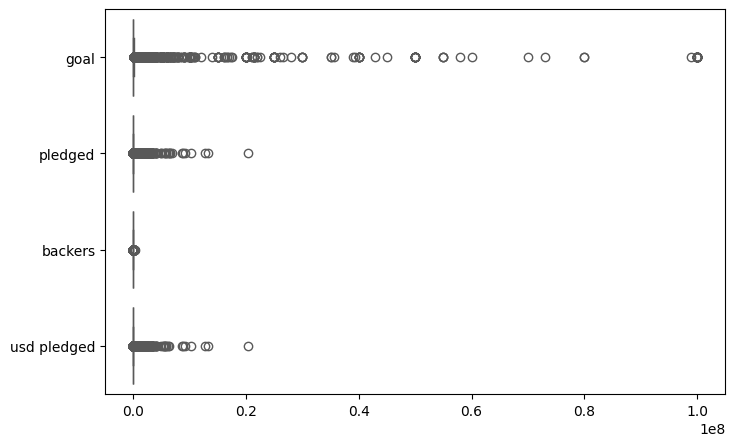

In [27]:
display(HTML("<h3>3.2 Выбросы</h3>"))
plt.figure(figsize=(8, 5))
sns.boxplot(data=data_numeric, orient="h", palette="Set2")
plt.show()

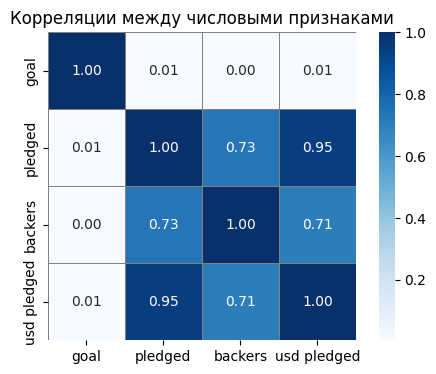

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Корреляции между числовыми признаками")
plt.show()


# 4. Пропущенные значения

In [32]:
data_cleaned = data.loc[:, ~data.columns.str.contains('^Unnamed')]

missing_counts = data_cleaned.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
display(HTML(missing_counts.to_frame("Количество пропусков").to_html(index=True)))

data_cleaned = data_cleaned.assign(
    **{
        "usd pledged": data_cleaned["usd pledged"].fillna(0),
        "category": data_cleaned["category"].fillna("Unknown"),
        "name": data_cleaned["name"].fillna("Unnamed Project"),
    }
)
data_cleaned = data_cleaned.dropna(subset=["goal", "pledged", "backers"])

,Количество пропусков
usd pledged,4413
goal,632
pledged,624
backers,623
category,5
name,4


# 5. Обработка категориальных признаков

In [34]:
categorical_cols = ['category', 'main_category', 'currency', 'country']

data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols, drop_first=True)

display(HTML(f"<b>Количество категориальных признаков:</b> {len(categorical_cols)}"))
display(HTML(f"<b>Размерность после кодирования:</b> {data_encoded.shape[0]} строк, {data_encoded.shape[1]} столбцов"))


# 6.  Нормализация

In [35]:
numeric_cols = data_encoded.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
data_scaled = data_encoded.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data_encoded[numeric_cols])

display(HTML(f"<b>Количество нормализованных признаков:</b> {len(numeric_cols)}"))

# 7. Выбор классификатора

## Выбор классификатора: RandomForestClassifier

**RandomForestClassifier** был выбран для классификации благодаря способности эффективно обрабатывать многоклассовые задачи с несбалансированными данными, работать с разнотипными признаками без обязательного масштабирования и обеспечивать интерпретируемость через оценку важности признаков, что делает его оптимальным решением для данной задачи.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

numeric_cols = ['goal', 'pledged', 'backers', 'usd pledged']
categorical_cols = ['category', 'main_category', 'currency', 'country']

X = data_cleaned[numeric_cols + categorical_cols].copy()
y = data_cleaned['state'].copy()

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n Точность на тестовой выборке: {acc:.4f}\n")

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df.style.background_gradient(cmap='Blues').format({
    'precision': "{:.2f}", 'recall': "{:.2f}", 'f1-score': "{:.2f}", 'support': "{:.0f}"
}))



 Точность на тестовой выборке: 0.8238



,precision,recall,f1-score,support
canceled,0.23,0.16,0.19,6471
failed,0.83,0.86,0.85,33644
live,0.09,0.07,0.08,886
successful,0.96,0.99,0.98,22616
suspended,0.02,0.03,0.02,296
undefined,0.93,0.98,0.95,711
accuracy,0.82,0.82,0.82,1
macro avg,0.51,0.52,0.51,64624
weighted avg,0.81,0.82,0.81,64624


# 8. Вычисление ошибок на обучающей и тестовой выборках


Точность на обучающей выборке: 0.9481
Точность на тестовой выборке: 0.8238


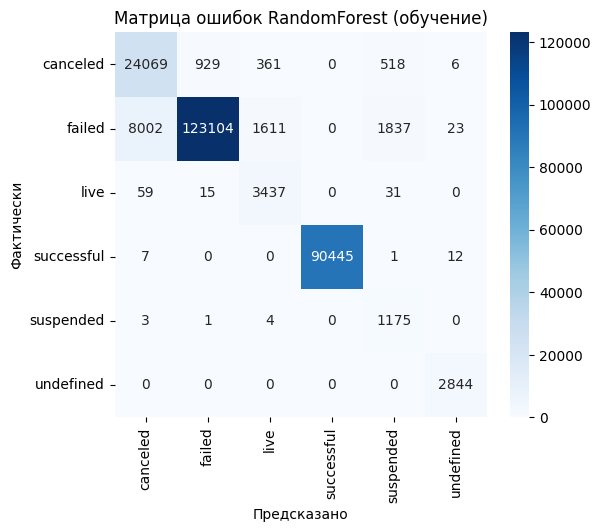

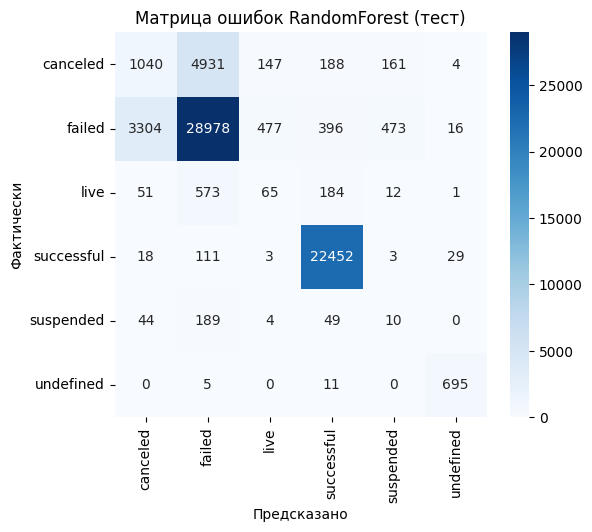


Комментарий:
- Если точность на обучении сильно выше тестовой — возможен переобучение.
- Посмотрите на классы с малым количеством примеров (например, 'canceled'), они чаще ошибаются.
- RandomForest хорошо справляется с несбалансированными классами благодаря class_weight='balanced'.


In [22]:
from sklearn.metrics import confusion_matrix

y_train_pred = rf.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_pred)

print(f"Точность на обучающей выборке: {acc_train:.4f}")
print(f"Точность на тестовой выборке: {acc_test:.4f}")

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок RandomForest (обучение)")
plt.show()

cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок RandomForest (тест)")
plt.show()


# 9. Сравнение с классификатором ближайших соседей

KNN (k=5) точность:
- Обучающая выборка: 0.8407
- Тестовая выборка: 0.7958



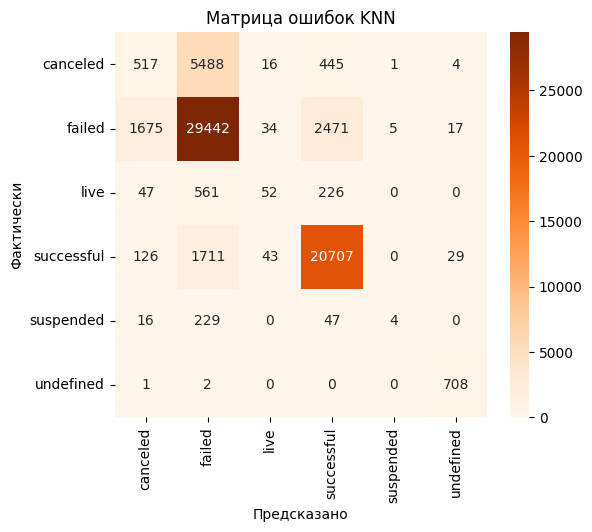

RandomForest vs KNN:
- RandomForest тестовая точность: 0.8238
- KNN тестовая точность: 0.7958

Комментарий:
- RandomForest обычно лучше справляется с большим числом признаков и категориальными переменными после one-hot кодирования.
- KNN чувствителен к масштабированию, числовые признаки важно нормализовать (у нас это сделано).
- KNN может работать хуже при несбалансированных классах или при больших выборках.


In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_train_pred_knn = knn.predict(X_train)
y_test_pred_knn = knn.predict(X_test)

acc_train_knn = accuracy_score(y_train, y_train_pred_knn)
acc_test_knn = accuracy_score(y_test, y_test_pred_knn)

print("KNN (k=5) точность:")
print(f"- Обучающая выборка: {acc_train_knn:.4f}")
print(f"- Тестовая выборка: {acc_test_knn:.4f}\n")

cm_knn = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title("Матрица ошибок KNN")
plt.show()

## Сравнение RandomForest и KNN

На тестовой выборке RandomForest показал точность **82.38%**, тогда как KNN — **79.58%**.  

Как и ожидалось, **RandomForest** работает лучше при большом числе признаков и категориальных переменных после one-hot кодирования. **KNN** немного уступает, так как чувствителен к масштабированию и может хуже справляться при несбалансированных классах или больших выборках.  

Тем не менее, **KNN также может использоваться** в задачах классификации Kickstarter-проектов, особенно при небольшом объеме данных и правильно подобранном числе соседей `k`.  

Вывод: RandomForest предпочтительнее для основной модели, но KNN может служить альтернативой или быть частью ансамбля моделей.


# Общие выводы

1. **Цель и результаты**  
   Построены модели для прогнозирования успешности краудфандинговых проектов на платформе Kickstarter с использованием категориальных и числовых признаков, включая категорию проекта, страну, финансовые показатели и количество спонсоров.

2. **Сравнение моделей**  
   RandomForest показал точность **82.38%**, эффективно обрабатывая категориальные признаки и несбалансированные классы. KNN продемонстрировал точность **79.58%**, но чувствителен к масштабированию и размеру выборки.

3. **Вывод**  
   RandomForest является предпочтительной моделью для прогнозирования успешности проектов, тогда как KNN может выступать альтернативой или частью ансамбля при тщательной настройке гиперпараметров.
